In [96]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [97]:
from ctw.tree import Tree, view_tree, TreeNode, __visualize_tree
from ctw.models import ARTree, Quantizer

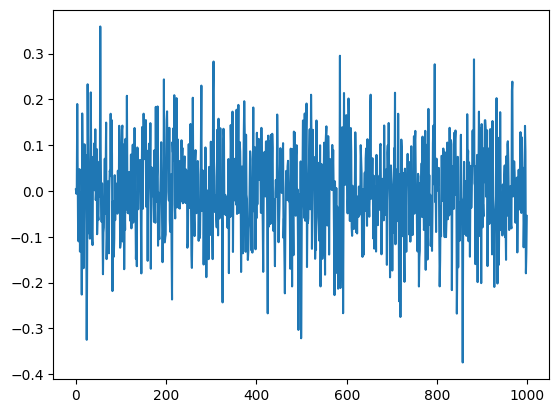

In [ ]:
from ctw.series import AR

from matplotlib import pyplot as plt

ar_model =AR(p = 2, coeffs= [0.2, -0.1], sigma = 0.1, n_sample=1000)
x = [data for data in ar_model]
plt.plot(x)


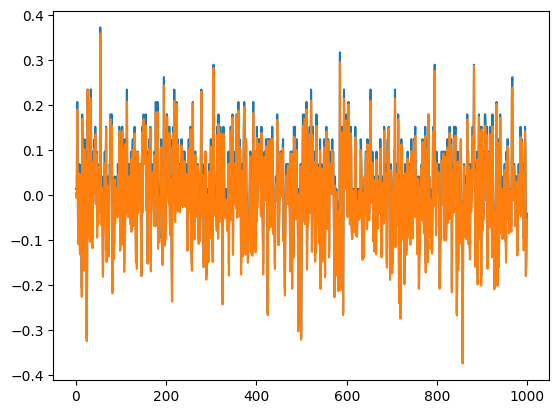

In [311]:
import numpy as np
thresholds = np.linspace(-0.4, 0.4, 30)
quantizer = Quantizer(thresholds=thresholds)

quantized_x = [quantizer.quantize(xi) for xi in x]

unquantized_x = [quantizer.unquantize(qi) for qi in quantized_x]
plt.plot(unquantized_x)
plt.plot(x)


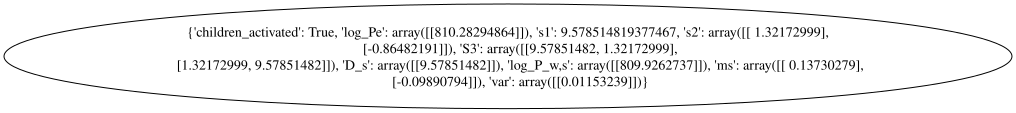

In [312]:
ar_tree = ARTree(max_depth=2, order=2, quantizer=quantizer)
ar_tree.build_from_string(x[:5])
ar_tree.compute_ctw(x)
# view_tree(ar_tree.tree)
ar_tree.compute_bct(x)
# view_tree(ar_tree.tree)
ar_tree.compute_map_parameters()
view_tree(ar_tree.tree)



In [318]:
from ctw.models import LiveARTree

# view_tree(live_ar_tree.tree)

In [319]:
live_ar_tree = LiveARTree(max_depth=2, order=2, quantizer=quantizer)
y = x[::]
for x_i in y:
    live_ar_tree.observe(x_i)
print('a')
ar_tree = ARTree(max_depth=2, order=2, quantizer=quantizer)
ar_tree.build_from_string(y)
ar_tree.compute_ctw(y)
ar_tree.compute_bct(y)
ar_tree.compute_map_parameters()

print('b')
# view_tree(ar_tree.tree)

a
b


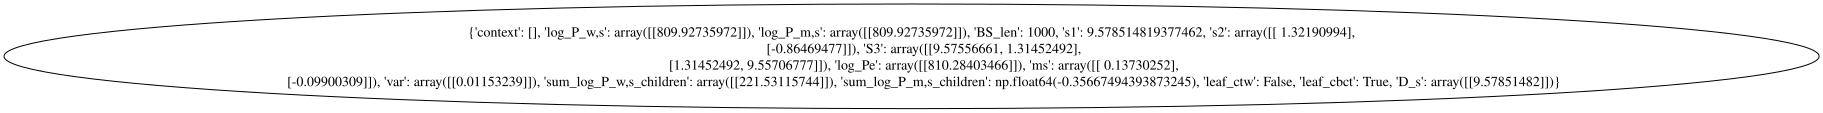

In [316]:
view_tree(live_ar_tree.tree)

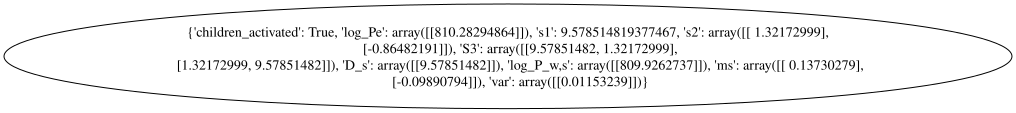

In [317]:
view_tree(ar_tree.tree)

[0.0642236964353574, 0.1990303273378681, 0.15799751623369362, 0.11748188527443626, 0.04348924416960746, 0.02103459926495535, -0.19022224068355417, -0.18618486665938155, 0.2022470379789671, -0.24063630301012712]
[[0.]
 [0.]]
[[0.]
 [0.]]
[[0.]
 [0.]]
[[ 1.47175274]
 [-1.69092226]]
[[ 1.14117307]
 [-0.37871878]]
[[ 1.16953344]
 [-0.47395151]]
[[ 1.12495707]
 [-0.40133122]]
[[ 1.21554135]
 [-0.57436606]]
[[ 1.05445347]
 [-0.43873493]]
[[ 0.92759684]
 [-0.82577179]]
[[-0.00507235]
 [ 0.23825625]]
[[-0.18884421]
 [ 0.43903258]]
[[-0.03089154]
 [ 0.2319668 ]]
[[-0.19966871]
 [-0.13769128]]
[[ 0.06564586]
 [-0.18455774]]
[[ 0.1120145 ]
 [-0.08335197]]
[[ 0.10105761]
 [-0.15871184]]
[[ 0.10753601]
 [-0.16142535]]
[[ 0.10041843]
 [-0.20378471]]
[[ 0.16004684]
 [-0.22671252]]
[[ 0.22297707]
 [-0.18700801]]
[[ 0.19466759]
 [-0.23199587]]
[[ 0.12750611]
 [-0.14709575]]
[[ 0.22397919]
 [-0.22146553]]
[[ 0.19499641]
 [-0.23632777]]
[[ 0.19652525]
 [-0.24238228]]
[[ 0.19251564]
 [-0.24320371]]
[[ 0.1

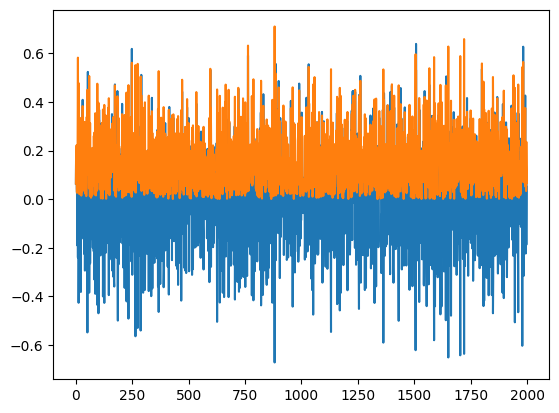

In [356]:

x = [x_i for x_i in AR(p=2, coeffs=[0.1, -0.2], sigma=0.2, n_sample=2000)]
quantizer = Quantizer(thresholds=np.linspace(-0.006, 0.006, 20))

plt.plot(x)
print(x[:10])
# Draw error curve between predicted and actual values
live_ar_tree = LiveARTree(max_depth=2, order=2, quantizer=quantizer)
predictions = []
actuals = []
for x_i in x:
    prediction = live_ar_tree.predict(live_ar_tree._x[-2:])
    predictions.append(prediction)
    actuals.append(x_i)
    live_ar_tree.observe(x_i)
    
errors = [abs(p - a) for p, a in zip(predictions, actuals)]
plt.plot(errors)


print(live_ar_tree.tree.root.data)

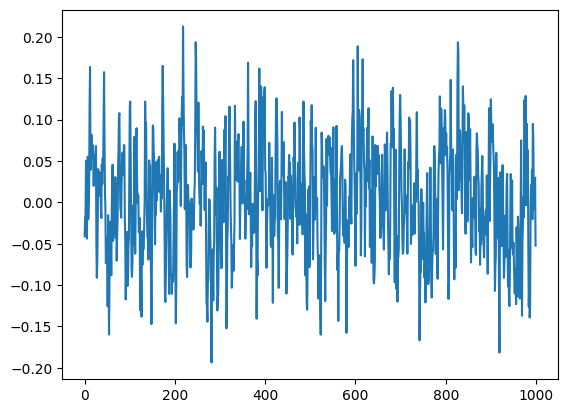

In [ ]:
import numpy as np

def generate_setar_data(n_samples=2000, threshold=0.0, delay=1, sigma=0.1):
    """
    Generates data from a 2-regime SETAR model.
    Regime 1 (Low): x_t = 0.8 * x_{t-1} - 0.2 * x_{t-2} + eps
    Regime 2 (High): x_t = -0.5 * x_{t-1} + eps
    """
    p = 1  # Max order
    x = np.zeros(n_samples + p)
    
    # Coefficients for the two regimes
    phi_low = np.array([0.8, -0.2])
    phi_high = np.array([-0.5, 0.0]) # AR(1) effectively
    
    for t in range(p, n_samples + p):
        # The 'Self-Exciting' part: check the value at the delay lag
        z_t = x[t - delay]
        
        noise = np.random.normal(0, sigma)
        
        if z_t <= threshold:
            # Regime 1 logic
            x[t] = phi_low[0] * x[t-1] + phi_low[1] * x[t-2] + noise
        else:
            # Regime 2 logic
            x[t] = phi_high[0] * x[t-1] + phi_high[1] * x[t-2] + noise
            
    return x[p:]

# Generate and visualize
setar_series = generate_setar_data(n_samples=1000, threshold=0.5, sigma=0.05)
plt.plot(setar_series)

quantizer = Quantizer(thresholds=np.linspace(-1.0, 1.0, 50))
ar_tree = ARTree(max_depth=2, order=2, quantizer=quantizer)
ar_tree.build_from_string(setar_series)
ar_tree.compute_ctw(setar_series)
ar_tree.compute_bct(setar_series)
ar_tree.compute_map_parameters()
view_tree(ar_tree.tree)
